In [1]:
import numpy as np
import datetime
import pandas as pd
import random

In [2]:
#X=pd.read_csv('nifty.csv')
#len(X)

In [3]:
def data1():
    X=pd.read_csv('tempcnnlstmcluster.csv')
    X = X.iloc[60:]  # Keep rows from index 19 onwards (0-based index)
    # Ensure 'Open' and 'Close' are treated as numeric
    X['cashopen']=0
    X['cash']=0
    # Ensure columns have float dtype before assignment
    X['cashopen'] = X['cashopen'].astype(float)
    X['cash'] = X['cash'].astype(float)
    X['action']=""
    X['diff']=""
    X['quantity']=""
    return X
    

In [4]:
X=data1()
print(len(X))

2785


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


C:\Users\IIITNAGPUR\AppData\Roaming\Python\Python312\site-packages\IPython\core\magics\pylab.py:166: UserWarning: pylab import has clobbered these variables: ['random']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


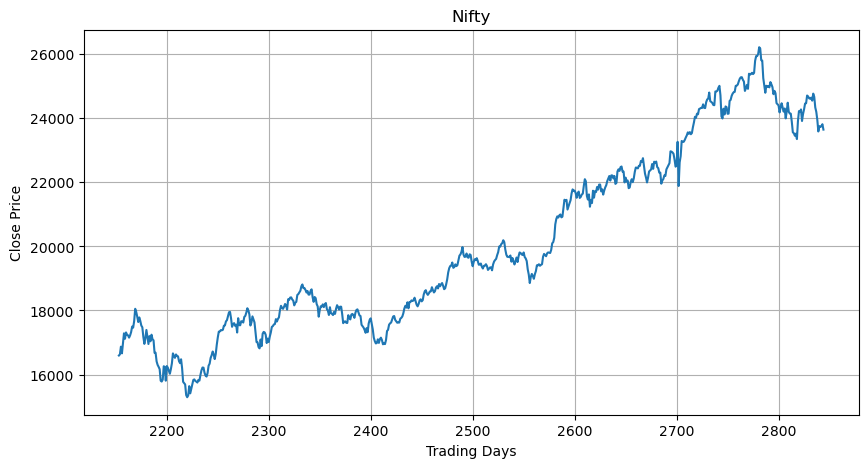

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
%pylab inline
fig = plt.figure()
ax=X.loc[2153:2889,'Close'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("Close Price")
plt.show()
fig.savefig('nifty_close.png')

In [6]:
len(X)

2785

In [7]:
X['Cluster'].value_counts()

Cluster
2.0    656
3.0    472
0.0    435
4.0    396
1.0    296
6.0    269
5.0    149
7.0    112
Name: count, dtype: int64

In [8]:
X.head()

,Unnamed: 0.1,Unnamed: 0,index,Close,High,Low,Open,Volume,date,weekday,...,cnnstate,p_co,state2d,state1d,Cluster,cashopen,cash,action,diff,quantity
60,60,60,160,5471.750000,5478.799805,5377.799805,5428.750000,251500,23-08-2013,1.00,...,0.0,0.505321,3.0,5.0,4.0,0.0,0.0,,,
61,61,61,161,5476.500000,5528.700195,5454.450195,5499.399902,242000,26-08-2013,0.00,...,0.0,-0.912992,0.0,2.0,3.0,0.0,0.0,,,
62,62,62,162,5287.450195,5427.399902,5274.250000,5426.500000,306000,27-08-2013,0.25,...,2.0,-1.021286,2.0,2.0,3.0,0.0,0.0,,,
63,63,63,163,5285.000000,5317.700195,5118.850098,5233.450195,336000,28-08-2013,0.50,...,2.0,0.596026,5.0,5.0,2.0,0.0,0.0,,,
64,64,64,164,5409.049805,5428.899902,5303.000000,5316.500000,326500,29-08-2013,0.75,...,2.0,-0.029573,2.0,2.0,3.0,0.0,0.0,,,


In [9]:
def getState(t):    
    t = int(t)
    return(X['Cluster'][t])  

In [10]:
class Agent:
    def __init__(self):
           
        self.gamma = np.load('rl/gamma100.npy')
        self.Q = np.load('rl/Qtable100.npy')
        self.learning_rate=np.load('rl/learning_rate100.npy')
        self.epsilon = np.load('rl/epsilon100.npy')
        print(self.epsilon)
    def getAction(self,state):
        state = int(state)
        a=[1,0,2]
        if np.random.rand() <= self.epsilon:
            pass
        #    return random.choice(a)
        return np.argmax(self.Q[state,])  
    
    # Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
    def update(self,state,action,reward,next_state,next_action):
        state = int(state)
        action = int(action)
        next_state = int(next_state)
        self.Q[state,action]= self.Q[state,action] + self.learning_rate * (reward + self.gamma * np.max(self.Q[next_state, :])
                                                                - self.Q[state,action])

        

In [11]:
episode_count=50
agent=Agent()
agent.Q
m1=0
m2=0
for e in range(1,episode_count+1):
    X=data1()
    
    data_length_start=2107
    data_length=2844
    state = getState(data_length_start)
    action = agent.getAction(state)
    
  
    capital=X.loc[data_length_start,'Open']*10
    margin=X.loc[data_length_start,'Open']*10
    X.loc[2,'cashopen']=margin 
    brok_rate=0.0000
    #brok_rate=0.0
    
    print("Episod {}/{}".format(e,episode_count))
    count=0
    for t in range(data_length_start,data_length):
                
        reward=0                        
         
        if action == 1:
            X.loc[t,'cashopen']=margin 
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=quantity
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=margin         
            
            #print('Long: open price @',X.loc[t,'Open'],'Close price @',X.loc[t,'Close'], 'profit=',tprofit)
            X.loc[t,'action']="long"
            X.loc[t,'diff']=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Close'])-np.log(X.loc[t,'Open']+tbrokerage)),0)
       
        elif action == 2:
            X.loc[t,'cashopen']=margin 
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=(-quantity)
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            #print('in Short')
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=margin         
            last_action='Short'
            #print('Short: Close price @',X.loc[t,'Close'],'Open price @',X.loc[t,'Open'], 'profit=',tprofit)
            X.loc[t,'action']="short"
            X.loc[t,'diff']=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Open'])-np.log(X.loc[t,'Close']+tbrokerage)),0)
        else:
            X.loc[t,'cash']=margin
            X.loc[t,'action']="Hold"
            X.loc[t,'diff']=0
            reward=0                                  
              
        next_state=getState(t)
        #print("Next state:", next_state)  # Debugging
        next_action=agent.getAction(next_state)
        agent.update(state,action,reward,next_state,next_action)
        state=next_state
        action=next_action
        
        if t==data_length-1:
                print("\n***********************\n")
                print("Profit is ",(margin-capital))
                print("Initial Capital is ",capital)    
                print("Current Capital is ",margin)
                roi=((margin-capital)/capital)*100
                print("%ROI is ",roi)
                bnh=((X.loc[t,'Close']-X.loc[data_length_start,'Open'])/X.loc[data_length_start,'Open'])*100
                print("% Buy and Hold=",bnh)
                print("count",count)
                print("qtable",agent.Q)
                print("epsilon",agent.epsilon)
                print("--------------------------------")
                       
       
    
    m3=roi
    if m3>m2:
          m1=e
          m2=m3
        #To save model  
    if e%1==0:
            np.save('rl/test/Qtable'+ str(e)+str('.npy'), agent.Q)
            np.save('rl/test/epsilon'+ str(e)+str('.npy'), agent.epsilon)
            np.save('rl/test/gamma'+ str(e)+str('.npy'), agent.gamma)
            np.save('rl/test/learning_rate'+ str(e)+str('.npy'), agent.learning_rate)
            X.to_csv('csv1/AfterTest'+str(e)+str('.csv'))
print("e={},roi={}".format(m1,m2))

0.009998671593271896
Episod 1/50

***********************

Profit is  220755.88073000204
Initial Capital is  173871.50389999998
Current Capital is  394627.384630002
%ROI is  126.96495732674344
% Buy and Hold= 36.95976543514558
count 737
qtable [[0.00968799 0.00953941 0.01012808]
 [0.0089255  0.00889487 0.01043702]
 [0.00806582 0.00984398 0.00877555]
 [0.00824249 0.00901795 0.00996262]
 [0.00792632 0.00791481 0.01125575]
 [0.00721319 0.01026553 0.00717389]
 [0.00893198 0.00895426 0.0089489 ]
 [0.0052925  0.01158596 0.005533  ]]
epsilon 0.009998671593271896
--------------------------------
Episod 2/50

***********************

Profit is  189643.11105999936
Initial Capital is  173871.50389999998
Current Capital is  363514.61495999934
%ROI is  109.0708407106608
% Buy and Hold= 36.95976543514558
count 709
qtable [[0.0085556  0.00857836 0.008808  ]
 [0.00809643 0.00810825 0.00807726]
 [0.00806582 0.00833505 0.00837995]
 [0.00824249 0.00844702 0.00840999]
 [0.00792632 0.00791481 0.00919123]
 

In [ ]:
agent.Q

In [ ]:
%matplotlib inline
#%pylab inline
fig = plt.figure()
ax=X.loc[data_length_start:data_length-1,'cash'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("cash")
plt.show()
#fig.savefig('baroda_close.png')